In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler ,MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score,davies_bouldin_score
import scipy.cluster.hierarchy as sch

In [2]:
df=pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')

# Data Profiling

In [3]:
df.shape

(200, 5)

In [4]:
df.head(3)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [5]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
print("Numerical Stats:")
display(df.describe().T)

Numerical Stats:


,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [9]:
print("Categorical Stats:")
display(df.describe(include='object').T)

Categorical Stats:


,count,unique,top,freq
Genre,200,2,Female,112


In [10]:
df = df.rename(columns={'Genre': 'Gender'})

In [11]:
df['Gender'].value_counts()

,count
Gender,
Female,112
Male,88


In [12]:
df.drop(columns=['CustomerID'], inplace=True)

# EDA

## **Univariate Analysis** (Age)

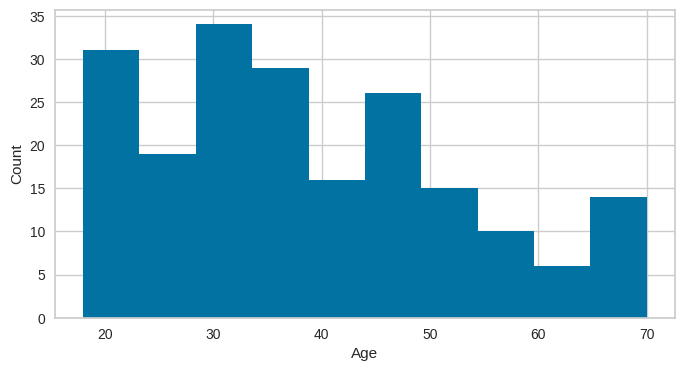

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(df['Age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [14]:
print(f"Average Customers' Age = {df['Age'].mean()}")

Average Customers' Age = 38.85


In [15]:
#age binning
bins = [18,30,50,70]
labels = ['young','adult','senior']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

In [16]:
age_density = df['age_group'].value_counts(normalize=True).sort_index()

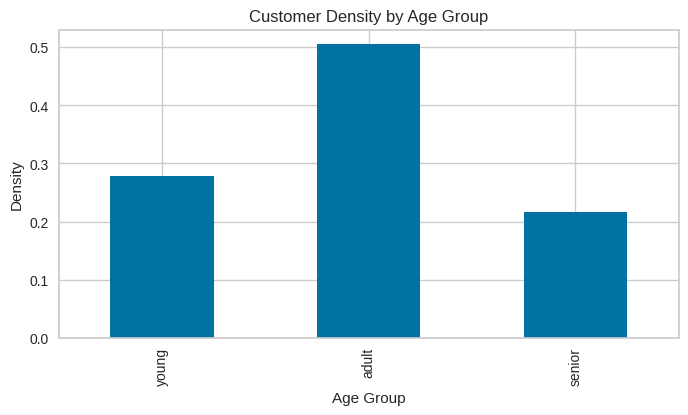

In [17]:
plt.figure(figsize=(8, 4))
age_density.plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Density')
plt.title('Customer Density by Age Group')
plt.show()

Text(0.5, 1.0, 'Count of Age Groups')

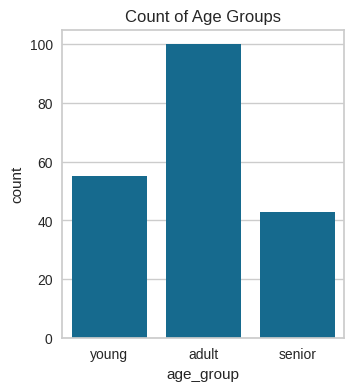

In [18]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='age_group', data=df)
plt.title('Count of Age Groups')

## **Univariate Analysis** (Annual Income)

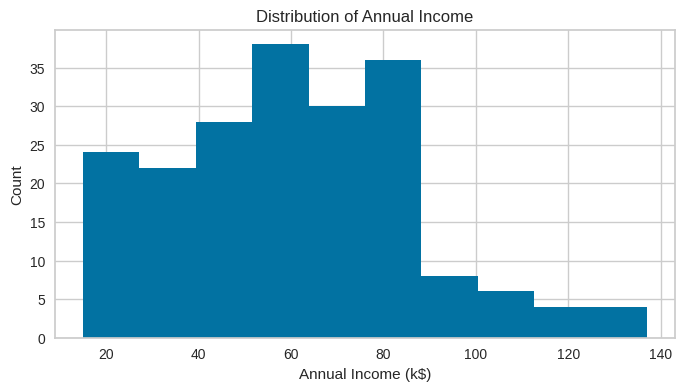

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(df['Annual Income (k$)'], bins=10)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Count')
plt.title('Distribution of Annual Income')
plt.show()

In [20]:
print(f"Average Customers' Annual Income = {df['Annual Income (k$)'].mean()}")

Average Customers' Annual Income = 60.56


In [21]:
#Income binning
bins = [0, 30, 60, 90, 200]
labels = ['low', 'medium', 'high', 'very high']
df['income_group'] = pd.cut(df['Annual Income (k$)'], bins=bins, labels=labels, right=False)

In [22]:
Income_density = df['income_group'].value_counts(normalize=True).sort_index()

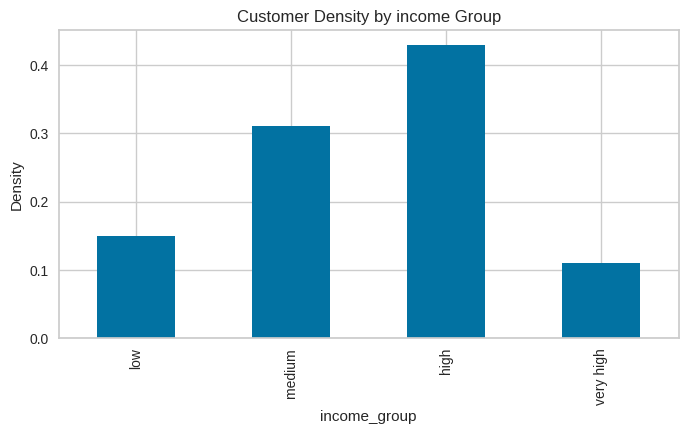

In [23]:
plt.figure(figsize=(8, 4))
Income_density.plot(kind='bar')
plt.xlabel('income_group')
plt.ylabel('Density')
plt.title('Customer Density by income Group')
plt.show()

## **Univariate Analysis** (Spending score)

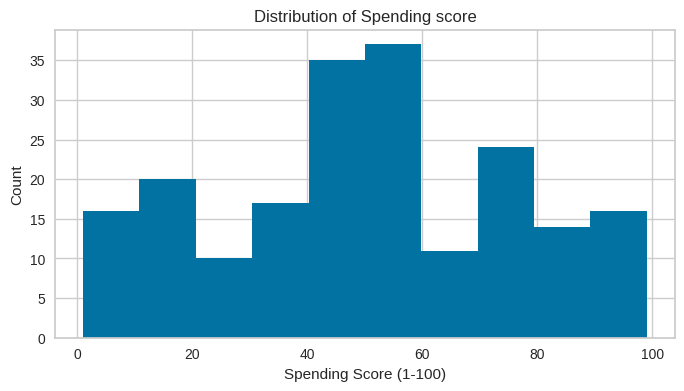

In [24]:
plt.figure(figsize=(8, 4))
plt.hist(df['Spending Score (1-100)'], bins=10)
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Count')
plt.title('Distribution of Spending score')
plt.show()

## **Bivariate Analysis**

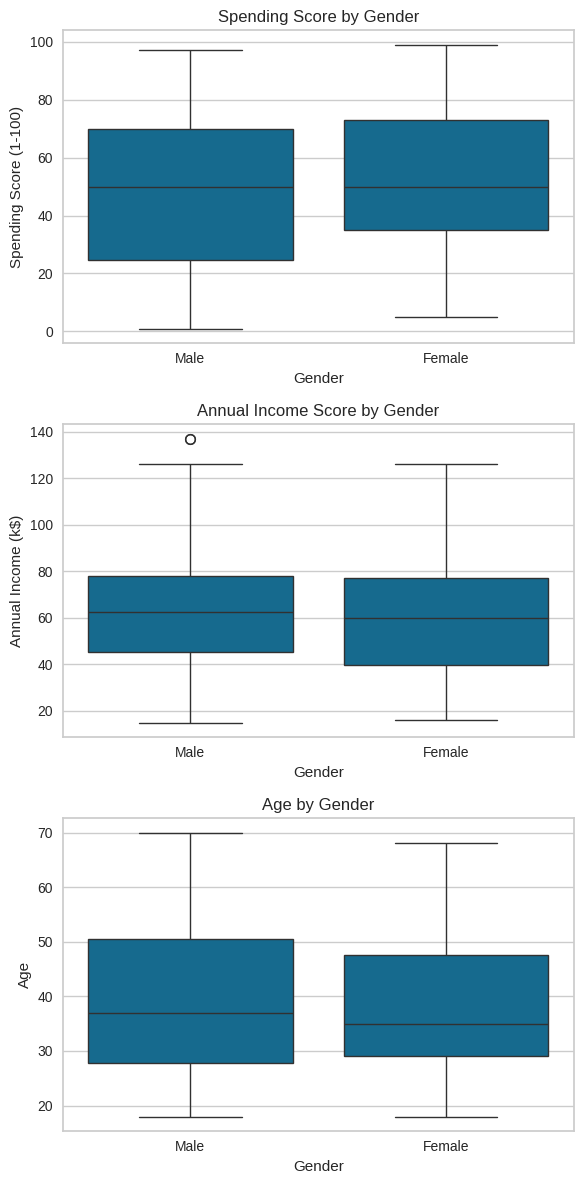

In [25]:
#features by 'Gender'
plt.figure(figsize=(6, 12))
plt.subplot(3, 1, 1)
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df)
plt.title('Spending Score by Gender')
plt.xlabel('Gender')

plt.subplot(3, 1, 2)
sns.boxplot(x='Gender', y='Annual Income (k$)', data=df)
plt.title('Annual Income Score by Gender')
plt.xlabel('Gender')

plt.subplot(3, 1, 3)
sns.boxplot(x='Gender', y='Age', data=df)
plt.title('Age by Gender')
plt.xlabel('Gender')

plt.tight_layout()
plt.show()

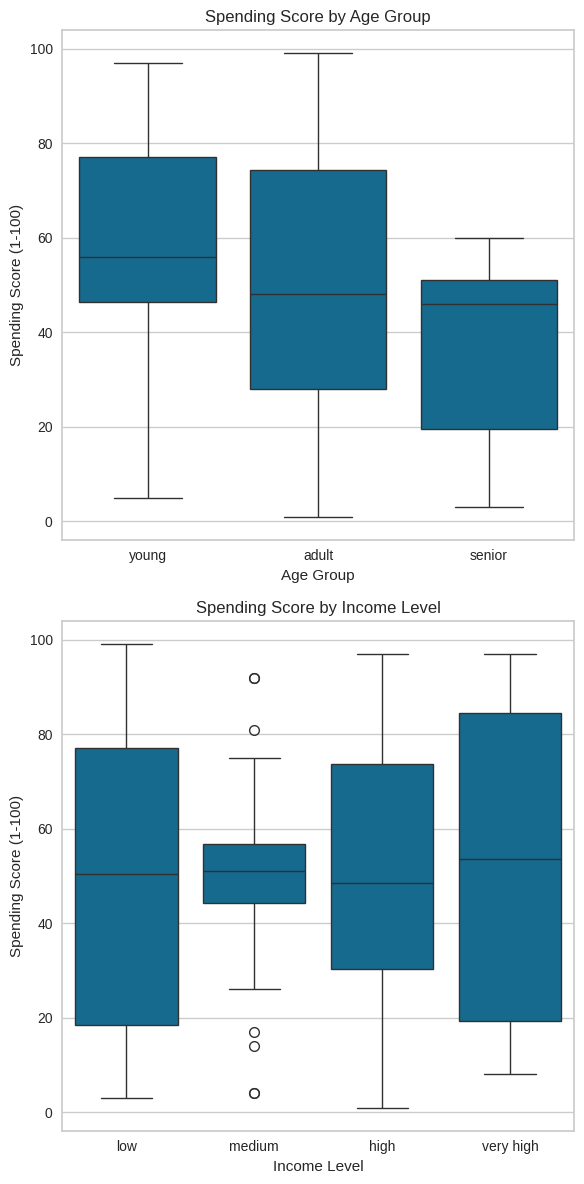

In [26]:
# features by 'Spending Score'
plt.figure(figsize=(6, 12))

plt.subplot(2, 1, 1)
sns.boxplot(x='age_group', y='Spending Score (1-100)', data=df)
plt.title('Spending Score by Age Group')
plt.xlabel('Age Group')

plt.subplot(2, 1, 2)
sns.boxplot(x='income_group', y='Spending Score (1-100)', data=df)
plt.title('Spending Score by Income Level')
plt.xlabel('Income Level')

plt.tight_layout()
plt.show()

## **Multivariate**

/tmp/ipykernel_556/3510942842.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_trend = df.groupby(['Age_Bin_5', 'Gender'])['Spending Score (1-100)'].mean().reset_index()


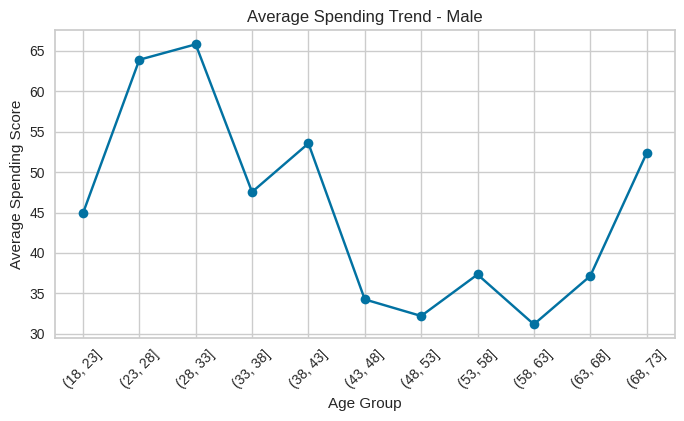

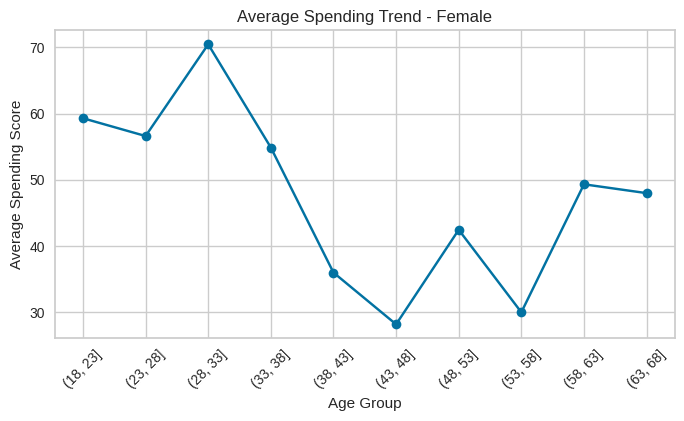

In [27]:
bins = range(df['Age'].min(), df['Age'].max() + 5,5)
df['Age_Bin_5'] = pd.cut(df['Age'], bins=bins)
age_trend = df.groupby(['Age_Bin_5', 'Gender'])['Spending Score (1-100)'].mean().reset_index()
male = age_trend[age_trend['Gender'] == 'Male']
female = age_trend[age_trend['Gender'] == 'Female']

#Male
plt.figure(figsize=(8, 4))
plt.plot(male['Age_Bin_5'].astype(str), male['Spending Score (1-100)'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Average Spending Score')
plt.title('Average Spending Trend - Male')
plt.xticks(rotation=45)
plt.show()

# Female
plt.figure(figsize=(8, 4))
plt.plot(female['Age_Bin_5'].astype(str), female['Spending Score (1-100)'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Average Spending Score')
plt.title('Average Spending Trend - Female')
plt.xticks(rotation=45)
plt.show()

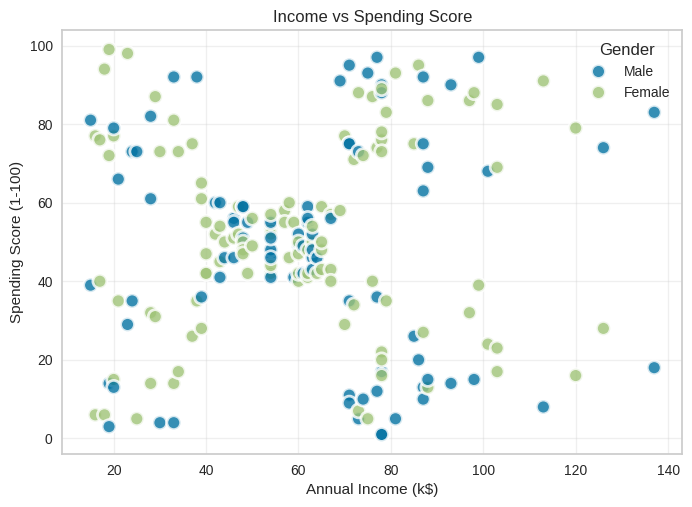

In [28]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',data=df, hue='Gender', s=100, alpha=0.8,edgecolor='white', linewidth=2)
plt.title('Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender', loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# K-means Clustering

In [29]:
X= df[["Annual Income (k$)", "Spending Score (1-100)"]] #Features Selection--2D

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

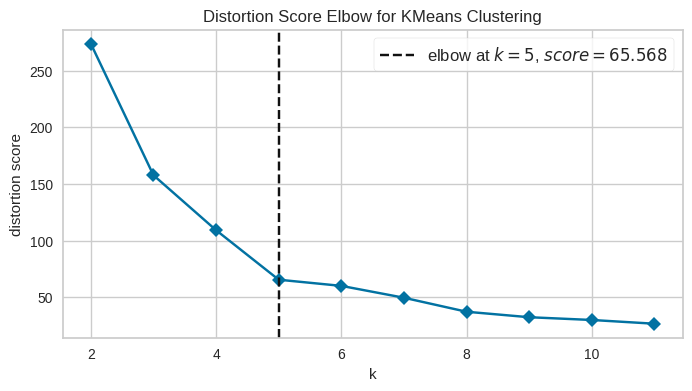

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [31]:
#Find the optimal K using elbow method
model_ = KMeans(random_state=42)
fig = KElbowVisualizer(model_, k=(2,12), timings=False)
plt.figure(figsize=(8, 4))
fig.fit(X_scaled)
fig.show()

In [32]:
k=5

In [33]:
model = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = model.fit_predict(X_scaled)

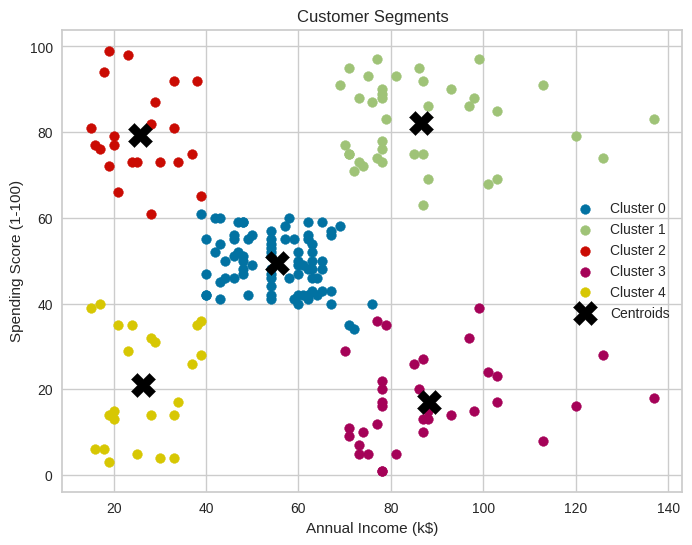

In [34]:
plt.figure(figsize=(8,6))
for cluster in range(k):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {cluster}'
    )

centroids = scaler.inverse_transform(model.cluster_centers_)
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    s=300, c='black', marker='X', label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.legend()
plt.show()

## *Trying Different Features* + *Hierarchical Clustering*

Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Silhouette Score: 0.3955454334726547


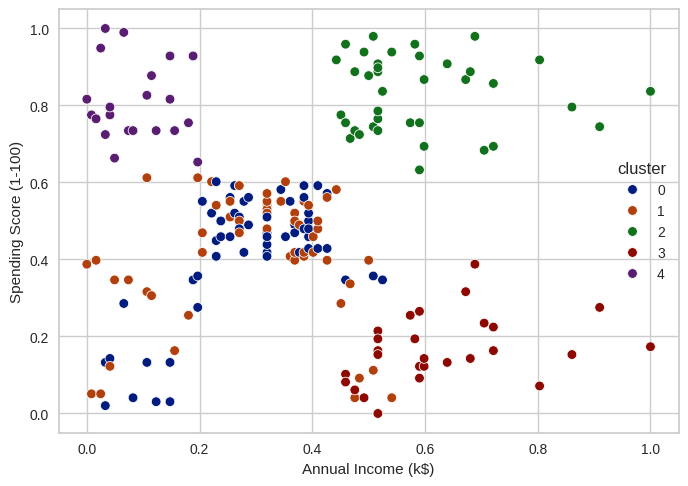

Features: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Silhouette Score: 0.35032447507156306


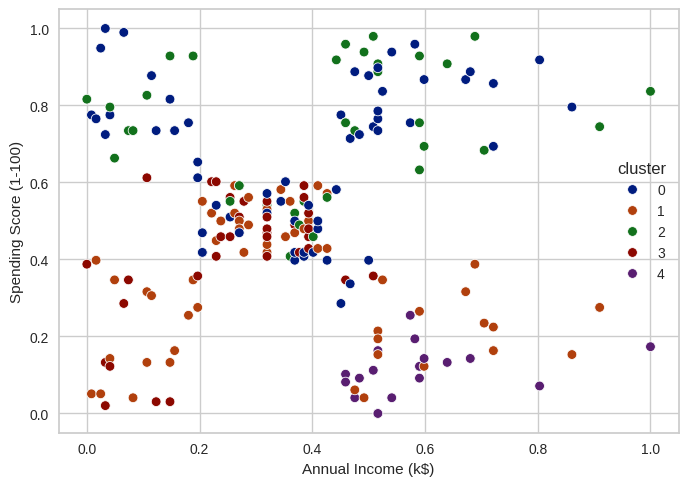

In [35]:
encoder=LabelEncoder()
df["Gender"]=encoder.fit_transform(df["Gender"])
features_3d=["Age","Annual Income (k$)","Spending Score (1-100)"]
features_4d=["Gender","Age","Annual Income (k$)","Spending Score (1-100)"]

for i in [features_3d,features_4d]:
    X=df[i]
    X_scaled=MinMaxScaler().fit_transform(X)
    X_scaled=pd.DataFrame(X_scaled,columns=i) #Converting back to dataframe for plotting.

    hc=AgglomerativeClustering(n_clusters=5)
    y_hc=hc.fit_predict(X_scaled)

    sil=silhouette_score(X_scaled,y_hc)
    print("Features:",i)
    print("\nSilhouette Score:",sil)
    X_scaled["cluster"]=pd.DataFrame(y_hc) #For plotting clusters
    sns.scatterplot(data=X_scaled,x="Annual Income (k$)",y="Spending Score (1-100)",hue="cluster",palette="dark")
    plt.show()

# DBSCAN Clustering

In [36]:
dbscan = DBSCAN(eps=0.4, min_samples=9)
clusters_dbscan = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = clusters_dbscan

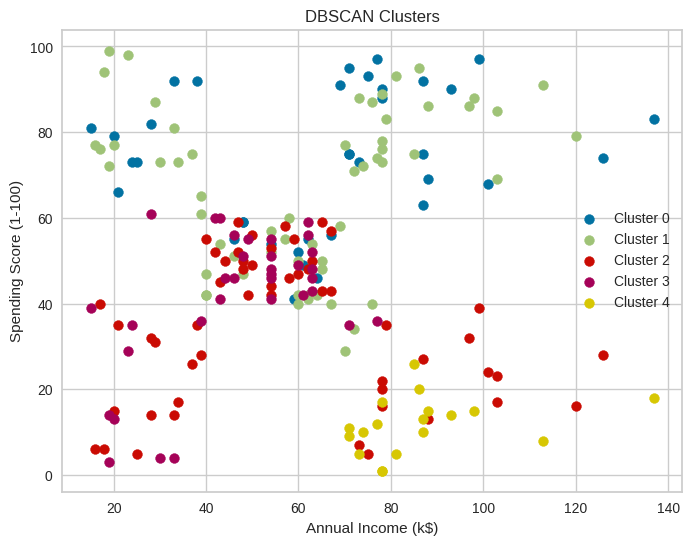

In [37]:
plt.figure(figsize=(8,6))
unique_clusters = np.unique(df['DBSCAN_Cluster'])

for cluster in unique_clusters:
    cluster_data = df[df['DBSCAN_Cluster'] == cluster]
    # Noise
    color = 'Black' if cluster == -1 else None
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {cluster}' if cluster != -1 else 'Noise',
        c=color,
        s=50
    )
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clusters')
plt.legend()
plt.show()

#Clusters Analysis & Insights

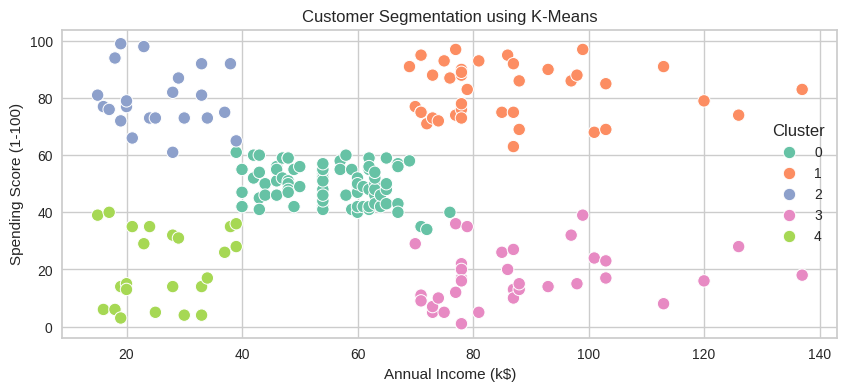

In [50]:
plt.figure(figsize=(10,4))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    s=80
)
plt.title('Customer Segmentation using K-Means')
plt.show()

In [38]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [42]:
cluster_names = {
    0: "Average Customers",
    1: "VIP Customers",
    2: "Impulsive Spenders",
    3: "Conservative Wealthy",
    4: "Budget Customers"
}

df['Segment'] = df['Cluster'].map(cluster_names)

In [43]:
df['Segment'].value_counts()

,count
Segment,
Average Customers,81
VIP Customers,39
Conservative Wealthy,35
Budget Customers,23
Impulsive Spenders,22


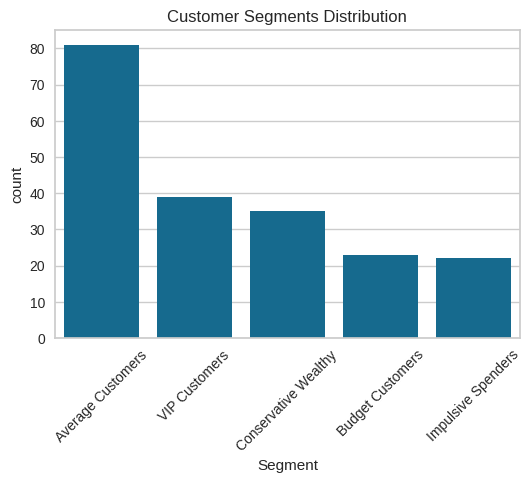

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Segment', order=df['Segment'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Customer Segments Distribution")
plt.show()

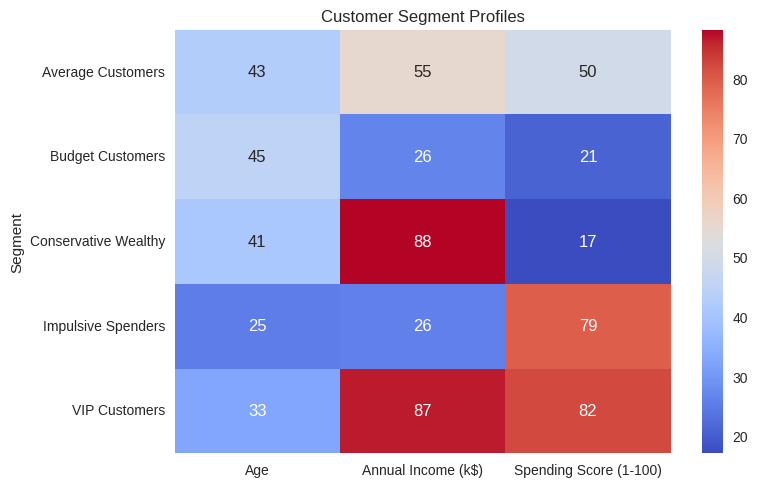

In [45]:
segment_profile = df.groupby('Segment')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()
sns.heatmap(segment_profile, annot=True, cmap="coolwarm")
plt.title("Customer Segment Profiles")
plt.show()

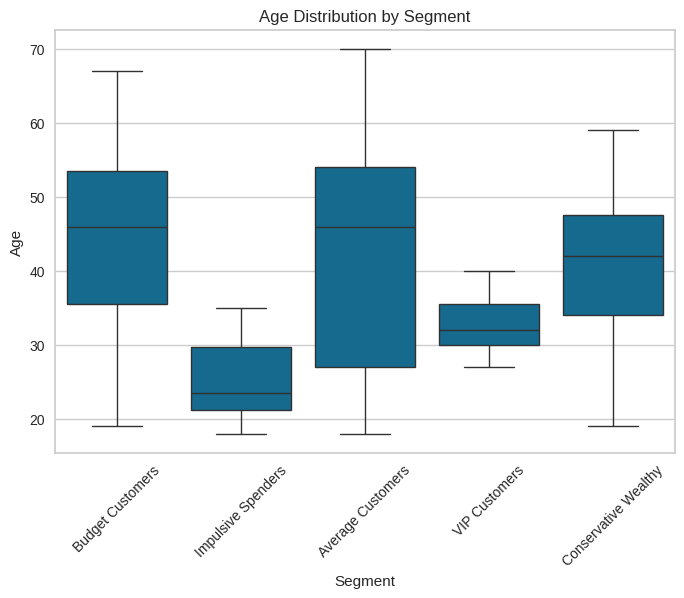

In [46]:
sns.boxplot(data=df, x='Segment', y='Age')
plt.xticks(rotation=45)
plt.title("Age Distribution by Segment")
plt.show()

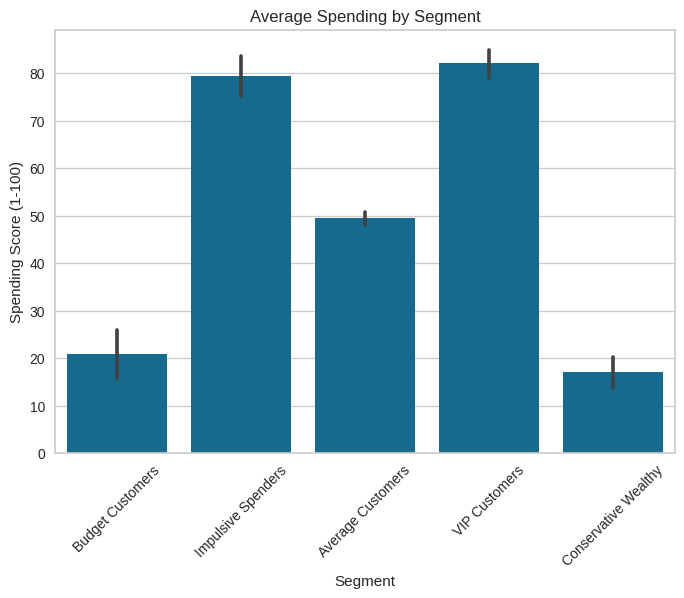

In [47]:
sns.barplot(
    data=df,
    x='Segment',
    y='Spending Score (1-100)',
    estimator='mean'
)

plt.xticks(rotation=45)
plt.title("Average Spending by Segment")
plt.show()

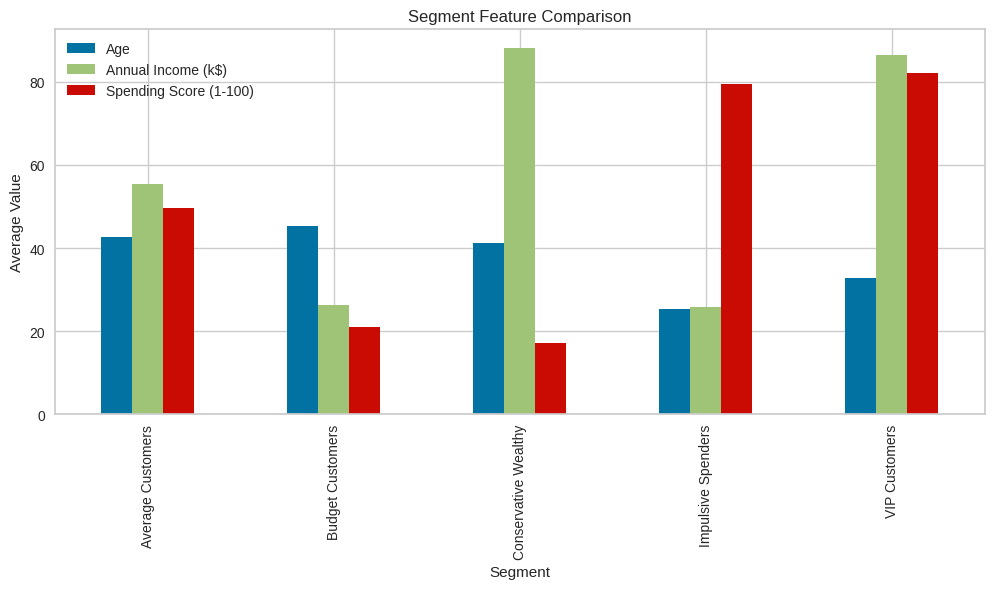

In [51]:
segment_profile.plot(kind='bar', figsize=(12,5))
plt.title("Segment Feature Comparison")
plt.ylabel("Average Value")
plt.show()